In [4]:
import os
from matplotlib.path import Path
import numpy as np
import pandas as pd
import contextily as ctx
import geodatasets
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path as SystemPath


ruta_paises = SystemPath("data/paises")
ruta_salida = SystemPath("data/unificado")

ruta_salida.mkdir(parents=True, exist_ok=True)

patron_busqueda = str(ruta_paises / "modis_2024_*.csv")
archivos_csv = glob.glob(patron_busqueda)

if archivos_csv:
    lista_dataframes = []
    
    for ruta_str in archivos_csv:
        archivo = SystemPath(ruta_str)
        pais = archivo.stem.replace("modis_2024_", "").capitalize() 
        
        df_temporal = pd.read_csv(archivo)
        df_temporal['pais'] = pais
        lista_dataframes.append(df_temporal)
    
    df_unificado = pd.concat(lista_dataframes, ignore_index=True)
    
    ruta_archivo_final = ruta_salida / "modis_2024_unificado.csv"
    df_unificado.to_csv(ruta_archivo_final, index=False)

df = pd.read_csv(r'data/unificado/modis_2024_unificado.csv')

## **Limpieza**

#### **Limpieza y Formateo de Fechas/Horas**

In [5]:
info_df = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Valores No Nulos': df.count(),
    'Valores Nulos': df.isnull().sum(),
    '% de Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})

print(" 1. INFO DE DATOS Y CALIDAD:")
display(info_df)  # Usamos display para mostrar ambas tablas de forma interactiva

print("\n 2. VISTA PREVIA DEL DATASET (Primeros registros):")
df.head()

 1. INFO DE DATOS Y CALIDAD:


,Tipo de Dato,Valores No Nulos,Valores Nulos,% de Nulos
latitude,float64,308402,0,0.0
longitude,float64,308402,0,0.0
brightness,float64,308402,0,0.0
scan,float64,308402,0,0.0
track,float64,308402,0,0.0
acq_date,object,308402,0,0.0
acq_time,int64,308402,0,0.0
satellite,object,308402,0,0.0
instrument,object,308402,0,0.0
confidence,int64,308402,0,0.0



 2. VISTA PREVIA DEL DATASET (Primeros registros):


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,pais
0,40.8143,19.6998,300.5,1.1,1.1,2024-01-28,853,Terra,MODIS,37,61.03,280.8,7.9,D,0,Albania
1,40.4384,19.7503,319.6,1.0,1.0,2024-01-28,1218,Aqua,MODIS,79,61.03,285.4,20.4,D,2,Albania
2,40.2651,19.8576,302.3,2.1,1.4,2024-01-31,1244,Aqua,MODIS,49,61.03,286.7,19.0,D,0,Albania
3,39.8510,20.2340,301.5,1.0,1.0,2024-02-04,1213,Aqua,MODIS,35,61.03,288.9,5.3,D,0,Albania
4,40.5204,20.3950,304.2,1.0,1.0,2024-02-04,1213,Aqua,MODIS,46,61.03,288.5,6.3,D,0,Albania


In [6]:
# Convertir la columna 'fecha' a tipo datetime
df['acq_date'] = pd.to_datetime(df['acq_date'], format='%Y-%m-%d')

# Formatear 'acq_time' para que sea consistente con 0 a la izquierda
df['acq_time'] = df['acq_time'].astype(str).str.zfill(4)

# Creamos columna 'acq_datetime' combinando 'acq_date' y 'acq_time'
df['acq_datetime'] = pd.to_datetime(
    df['acq_date'].dt.strftime('%Y-%m-%d') + ' ' + df['acq_time'].str[:2] + ':' + df['acq_time'].str[2:4], format='%Y-%m-%d %H:%M')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308402 entries, 0 to 308401
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   latitude      308402 non-null  float64       
 1   longitude     308402 non-null  float64       
 2   brightness    308402 non-null  float64       
 3   scan          308402 non-null  float64       
 4   track         308402 non-null  float64       
 5   acq_date      308402 non-null  datetime64[ns]
 6   acq_time      308402 non-null  object        
 7   satellite     308402 non-null  object        
 8   instrument    308402 non-null  object        
 9   confidence    308402 non-null  int64         
 10  version       308402 non-null  float64       
 11  bright_t31    308402 non-null  float64       
 12  frp           308402 non-null  float64       
 13  daynight      308402 non-null  object        
 14  type          308402 non-null  int64         
 15  pais          308

#### **Validación y Filtrado de Calidad**

In [7]:
# Filtrar registros de coordenadas
# Latitud debe estar entre -90 y 90, longitud entre -180 y 180
df = df[
    (df['latitude'].between(-90, 90)) &
    (df['longitude'].between(-180, 180)) &
    (df['latitude'].notnull()) &
    (df['longitude'].notnull())
]

df = df[df['confidence'].between(0, 100)]


#### **Estandarizacion**

In [8]:
# Convertir variables categóricas para optimizar memoria 
df['satellite'] = df['satellite'].astype('category')
df['instrument'] = df['instrument'].astype('category')
df['daynight'] = df['daynight'].astype('category')
df['pais'] = df['pais'].astype('category')
df['type'] = df['type'].astype('category') # tipo de foco (forestal, volcán...)

# Redondear variables numéricas para homogeneizar datos y reducir memoria
df['brightness'] = df['brightness'].round(2) # temperatura de brillo del pixel medida en Kelvin (temperatura observada desde el espacio en la zona más caliente)
df['bright_t31'] = df['bright_t31'].round(2) # temperatura de brillo del pixel medida en infra-rojo (band 31) (temperatura de la superficie terrestre)
# brightness y bright_t31 se usan para contrastar y distinguir un incendio de otros objetos calientes (asfalto, volcanes)
df['frp'] = df['frp'].round(2) # fire radiative power (potencia radiactiva del fuego) medida en MW (megavatios). Es un indicador de la intensidad del incendio.

In [9]:
# Diccionario de mapeo oficial de MODIS
diccionario_tipos = {
    0: 'Incendio forestal/vegetación',
    1: 'Volcán',
    2: 'Industria/Foco estático',
    3: 'Otros/Fuera de rango'
}

# Aplicar el mapeo a la columna type
df['type'] = df['type'].map(diccionario_tipos)

# Asegurarnos de que se guarde como tipo categoría para optimizar
df['type'] = df['type'].astype('category')

# Verificar el cambio
print(df['type'].value_counts())

type
Incendio forestal/vegetación    279748
Industria/Foco estático          26770
Volcán                            1760
Otros/Fuera de rango               124
Name: count, dtype: int64


#### **Generacion de csv limpio**

In [10]:
# 1. Crear la carpeta 'data' si no existe en el entorno
os.makedirs('data', exist_ok=True)

# 2. Modificar la ruta de salida para incluir la carpeta
archivo_salida = 'data/modis_2024_unificado_limpio.csv'

# Guardar los datos limpios dentro de la carpeta (Cambiado df_clean por df)
df.to_csv(archivo_salida, index=False)

print(f"Dimensiones finales tras la limpieza: {df.shape}")
print(f"¡Base de datos limpia guardada como '{archivo_salida}'!")

df_clean = pd.read_csv(r'data/modis_2024_unificado_limpio.csv')
df_clean.head()



Dimensiones finales tras la limpieza: (308402, 17)
¡Base de datos limpia guardada como 'data/modis_2024_unificado_limpio.csv'!


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type,pais,acq_datetime
0,40.8143,19.6998,300.5,1.1,1.1,2024-01-28,853,Terra,MODIS,37,61.03,280.8,7.9,D,Incendio forestal/vegetación,Albania,2024-01-28 08:53:00
1,40.4384,19.7503,319.6,1.0,1.0,2024-01-28,1218,Aqua,MODIS,79,61.03,285.4,20.4,D,Industria/Foco estático,Albania,2024-01-28 12:18:00
2,40.2651,19.8576,302.3,2.1,1.4,2024-01-31,1244,Aqua,MODIS,49,61.03,286.7,19.0,D,Incendio forestal/vegetación,Albania,2024-01-31 12:44:00
3,39.8510,20.2340,301.5,1.0,1.0,2024-02-04,1213,Aqua,MODIS,35,61.03,288.9,5.3,D,Incendio forestal/vegetación,Albania,2024-02-04 12:13:00
4,40.5204,20.3950,304.2,1.0,1.0,2024-02-04,1213,Aqua,MODIS,46,61.03,288.5,6.3,D,Incendio forestal/vegetación,Albania,2024-02-04 12:13:00


## **Calida de los datos**

#### **Análisis de Calidad y Filtro de Ruido**

In [11]:
# Analizar la distribución de la calidad antes de limpiar
print("Distribución original de confianza:")
print(df_clean['confidence'].describe())

# Aplicar el filtro de ruido: Quedarnos solo con alertas de confianza Media y Alta (>= 50%)
df_sin_ruido = df_clean[df_clean['confidence'] >= 50].copy()

print(f"\nRegistros originales: {len(df_clean)}")
print(f"Registros tras eliminar ruido: {len(df_sin_ruido)}")
print(f"Falsos positivos/Ruido eliminado: {len(df_clean) - len(df_sin_ruido)} alertas.")

Distribución original de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64

Registros originales: 308402
Registros tras eliminar ruido: 231964
Falsos positivos/Ruido eliminado: 76438 alertas.


Distribución de los niveles de confianza:
count    308402.000000
mean         66.089393
std          24.753513
min           0.000000
25%          50.000000
50%          69.000000
75%          86.000000
max         100.000000
Name: confidence, dtype: float64


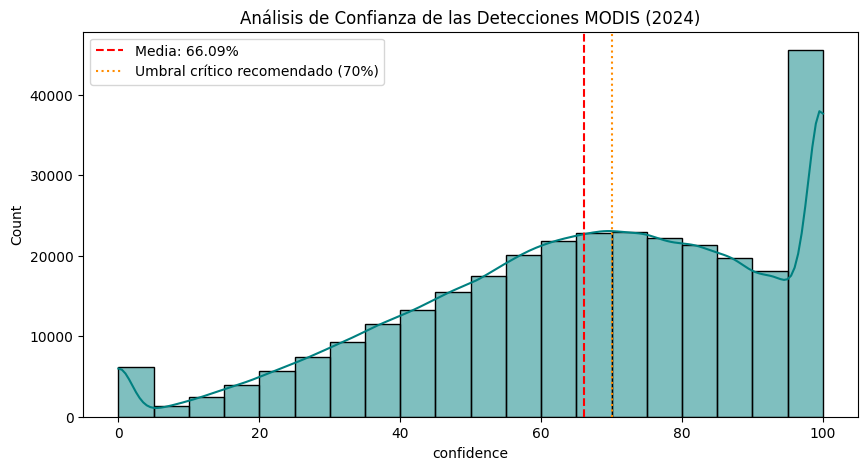

Registros iniciales: 308402 | Registros de alta confianza: 149734


In [12]:
# Resumen de calidad
print("Distribución de los niveles de confianza:")
print(df['confidence'].describe())

# Visualización de la pureza del dato
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='confidence', kde=True, bins=20, color='teal')
plt.axvline(df['confidence'].mean(), color='red', linestyle='--', label=f"Media: {df['confidence'].mean():.2f}%")
plt.axvline(70, color='darkorange', linestyle=':', label="Umbral crítico recomendado (70%)")
plt.title('Análisis de Confianza de las Detecciones MODIS (2024)')
plt.legend()
plt.show()

# Propuesta de filtrado para análisis de alta certeza
df_high_conf = df[df['confidence'] >= 70]
print(f"Registros iniciales: {len(df)} | Registros de alta confianza: {len(df_high_conf)}")

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\595022279.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\595022279.py:29: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


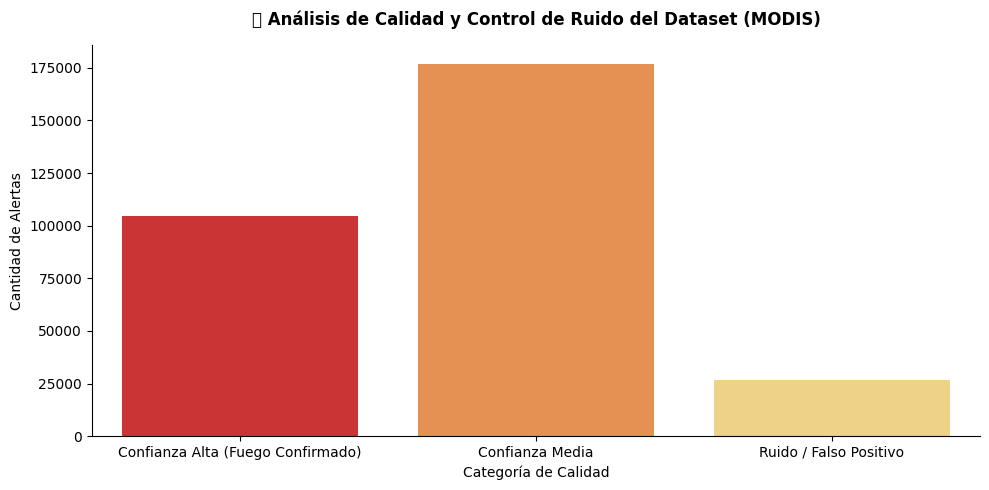

In [13]:
# Crear categorías de calidad basadas en el estándar MODIS
def clasificar_calidad(conf):
    if conf < 30:
        return 'Ruido / Falso Positivo'
    elif conf < 80:
        return 'Confianza Media'
    else:
        return 'Confianza Alta (Fuego Confirmado)'

# Aplicar la clasificación
df_clean['calidad_alerta'] = df_clean['confidence'].apply(clasificar_calidad)

# Graficar el análisis de calidad para la presentación
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean, 
    x='calidad_alerta', 
    palette='YlOrRd_r', 
    order=['Confianza Alta (Fuego Confirmado)', 'Confianza Media', 'Ruido / Falso Positivo']
)

plt.title('🛡️ Análisis de Calidad y Control de Ruido del Dataset (MODIS)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Categoría de Calidad', fontsize=10)
plt.ylabel('Cantidad de Alertas', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## **Iterpretacion Grafica**

#### **Análisis de Frecuencia por País**

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\3150678771.py:14: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


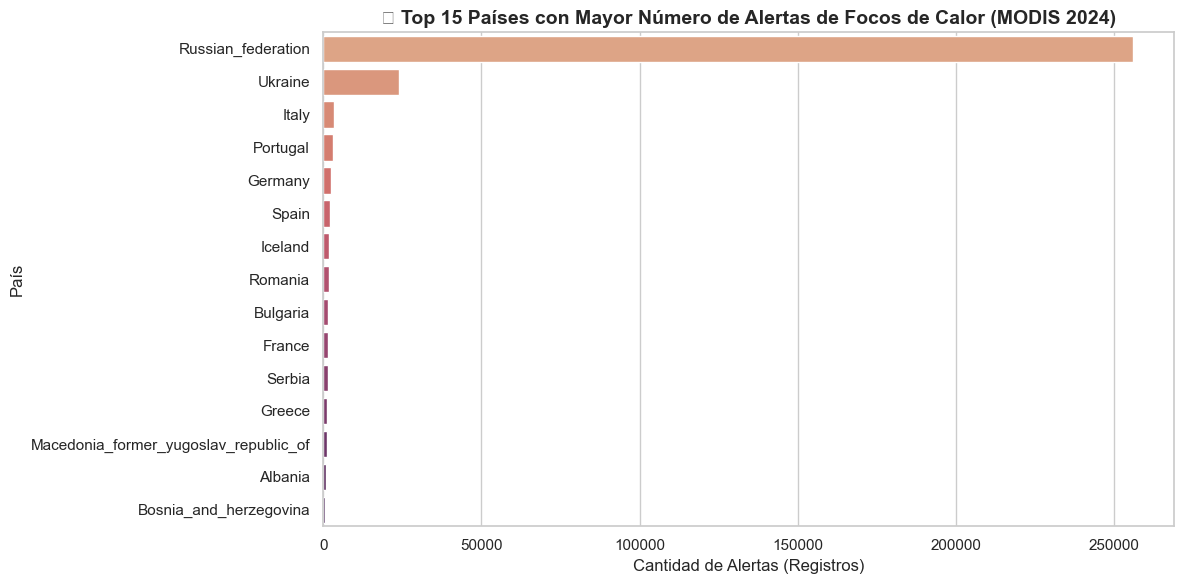

In [14]:
# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Contar registros por país y seleccionar los 15 principales
top_paises = df_clean['pais'].value_counts().head(15)

# Crear gráfico de barras
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette="flare", legend=False)

plt.title('🔥 Top 15 Países con Mayor Número de Alertas de Focos de Calor (MODIS 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Alertas (Registros)', fontsize=12)
plt.ylabel('País', fontsize=12)
plt.tight_layout()
plt.show()

#### **Comportamiento Temporal (Evolución por Meses)**

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\3832483875.py:36: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


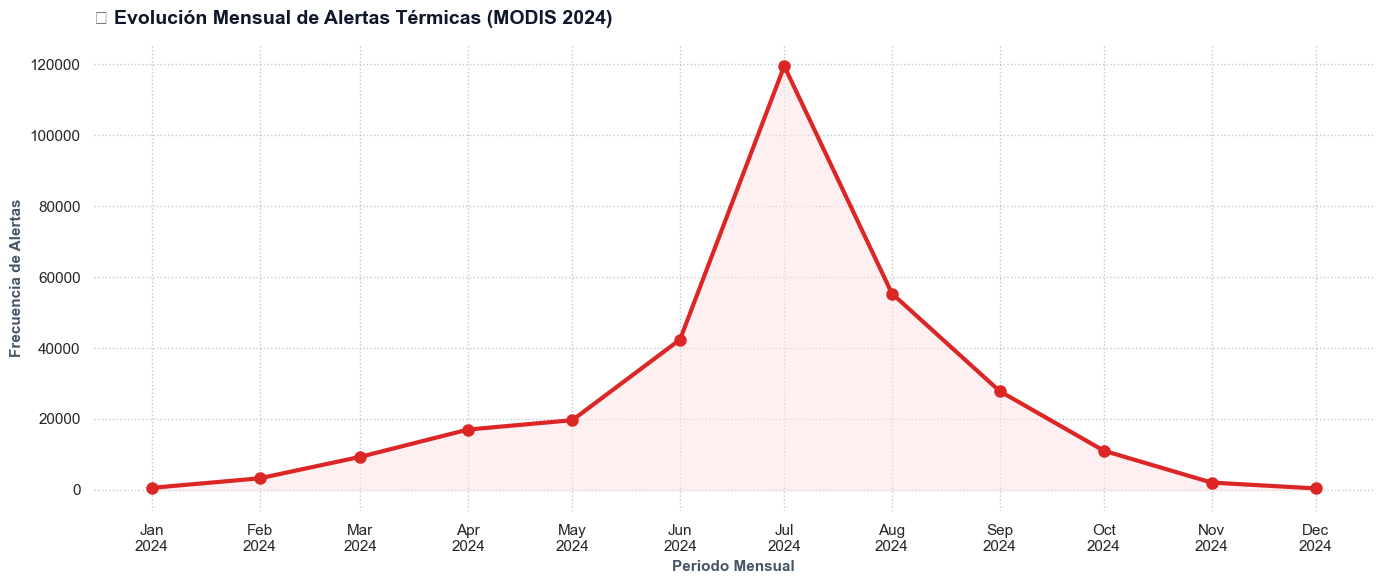

In [15]:
# 1. Estética nativa de Jupyter
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def plot_temporal_evolution(dataframe):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # === EL BLINDAJE REAL ===
    # Forzamos la conversión aquí mismo en una variable nueva
    fechas_correctas = pd.to_datetime(dataframe['acq_datetime'], errors='coerce')
    
    # ¡OJO AQUÍ!: Agrupamos usando 'fechas_correctas', NO 'dataframe'
    focos_por_mes = dataframe.groupby(fechas_correctas.dt.to_period('M')).size()
    focos_por_mes.index = focos_por_mes.index.to_timestamp()
    
    # 2. Gráfico y sombreado
    ax.plot(focos_por_mes.index, focos_por_mes.values, 
            marker='o', markersize=8, color='#dc2626', linewidth=3)
    
    ax.fill_between(focos_por_mes.index, focos_por_mes.values, 
                    color='#fee2e2', alpha=0.5) 
    
    # 3. Formato de fechas en el eje X
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    
    # 4. Etiquetas
    ax.set_title('📅 Evolución Mensual de Alertas Térmicas (MODIS 2024)', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a')
    ax.set_xlabel('Periodo Mensual', fontsize=11, fontweight='semibold', color='#475569')
    ax.set_ylabel('Frecuencia de Alertas', fontsize=11, fontweight='semibold', color='#475569')
    
    ax.grid(True, linestyle=':', alpha=0.6, color='#94a3b8')
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    return fig

# Lanzar el gráfico con tu df_clean
fig = plot_temporal_evolution(df_clean)
plt.show()

#### **Análisis de Dinámica Temporal y Estacionalidad de 2024**


📊 --- Comportamiento Agregado por Criterio Temporal ---
 mes_num mes_nombre trimestre  total_detecciones  frp_promedio  frp_maximo  confianza_media
       1        Ene        Q1                573     48.928272      2761.1        59.291449
       2        Feb        Q1               3262     25.254660      1337.9        60.426732
       3        Mar        Q1               9320     39.839378      2145.3        61.601073
       4        Abr        Q2              17010     38.466796      2572.6        63.724162
       5        May        Q2              19644     53.956205      9210.4        66.467216
       6        Jun        Q2              42383     54.495512      4161.2        65.083288
       7        Jul        Q3             119511     53.878182      5797.3        67.603877
       8        Ago        Q3              55367     53.518347      5696.2        65.773042
       9        Sep        Q3              27842     46.503689      5184.5        66.438079
      10        Oct    

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\356677911.py:73: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


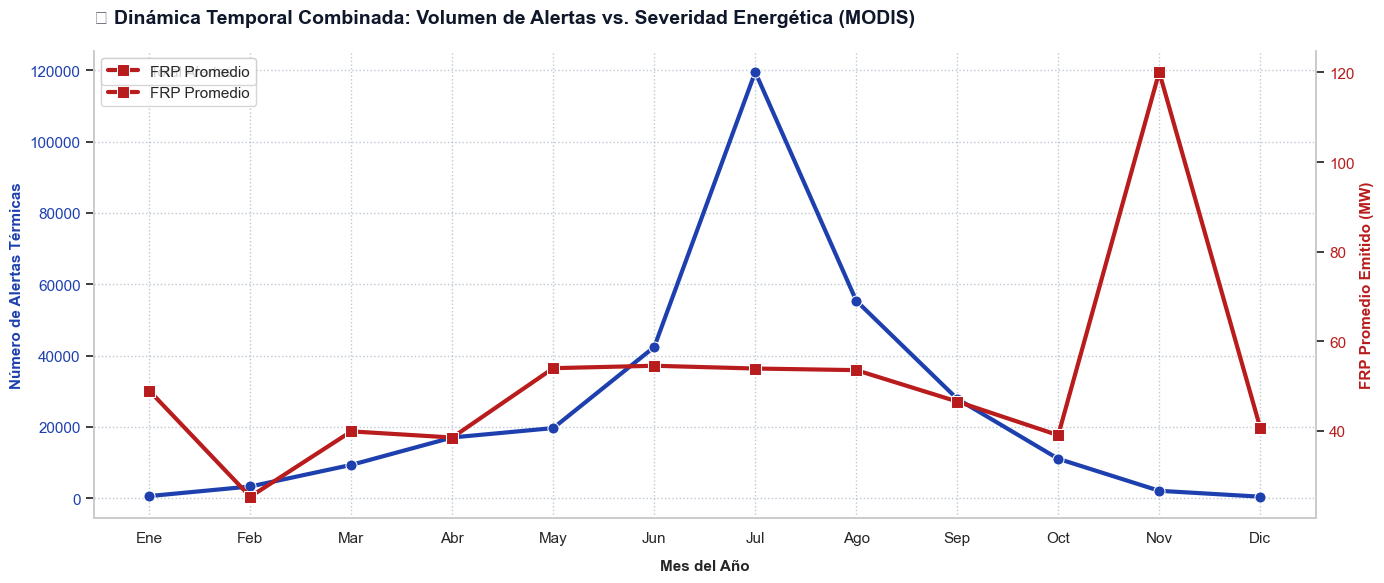

In [16]:
# 1. Configurar estética nativa de Jupyter / Colab
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 100

def generar_analisis_temporal_avanzado(dataframe):
    # Clonamos para no alterar el dataframe original
    df_temp = dataframe.copy()
    
    # Parsing estricto garantizado
    df_temp['acq_date'] = pd.to_datetime(df_temp['acq_date'], errors='coerce')
    
    # Crear características temporales legibles
    df_temp['mes_num'] = df_temp['acq_date'].dt.month
    
    # Diccionario para forzar los nombres de los meses en español (evita problemas de locale en Colab)
    meses_es = {
        1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
        7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
    }
    df_temp['mes_nombre'] = df_temp['mes_num'].map(meses_es)
    df_temp['trimestre'] = 'Q' + df_temp['acq_date'].dt.quarter.astype(str)
    
    # 2. Agrupación temporal corregida
    tabla_temporal = df_temp.groupby(['mes_num', 'mes_nombre', 'trimestre']).agg(
        total_detecciones=('frp', 'count'),
        frp_promedio=('frp', 'mean'),
        frp_maximo=('frp', 'max'),
        confianza_media=('confidence', 'mean')
    ).reset_index().sort_values('mes_num')
    
    print("\n📊 --- Comportamiento Agregado por Criterio Temporal ---")
    print(tabla_temporal.to_string(index=False))
    
    # 3. Construcción del Gráfico de Líneas Multieje Profesional
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    # Primer Eje (Izquierdo): Volumetría de alertas
    color_alertas = '#1e40af' # Azul oscuro técnico
    ax1.set_xlabel('Mes del Año', fontsize=11, fontweight='semibold', labelpad=10)
    ax1.set_ylabel('Número de Alertas Térmicas', color=color_alertas, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='total_detecciones', 
        marker='o', markersize=8, color=color_alertas, ax=ax1, linewidth=3, label='Total Alertas'
    )
    ax1.tick_params(axis='y', labelcolor=color_alertas)
    ax1.grid(True, linestyle=':', alpha=0.6, color='#94a3b8') # Rejilla sutil de fondo
    
    # Segundo Eje (Derecho): Severidad Energética (FRP)
    ax2 = ax1.twinx()
    color_frp = '#b91c1c' # Rojo fuego premium
    ax2.set_ylabel('FRP Promedio Emitido (MW)', color=color_frp, fontsize=11, fontweight='semibold')
    
    sns.lineplot(
        data=tabla_temporal, x='mes_nombre', y='frp_promedio', 
        marker='s', markersize=8, color=color_frp, ax=ax2, linewidth=3, label='FRP Promedio'
    )
    ax2.tick_params(axis='y', labelcolor=color_frp)
    ax2.grid(False) # Evitamos que las rejillas se crucen
    
    # Unificar leyendas de ambos ejes en una sola esquina limpia
    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', frameon=True)
    
    # Títulos y limpieza de bordes
    plt.title('📅 Dinámica Temporal Combinada: Volumen de Alertas vs. Severidad Energética (MODIS)', 
              fontsize=14, fontweight='bold', color='#0f172a', pad=20, loc='left')
    
    sns.despine(ax=ax1, top=True, left=False, right=False)
    sns.despine(ax=ax2, top=True, left=False, right=False)
    
    plt.tight_layout()
    return fig, tabla_temporal

# Lanzar proceso usando tu DataFrame df_clean
fig, tabla_resumen = generar_analisis_temporal_avanzado(df_clean)
plt.show()

#### **Análisis de Patrones Temporales y Estacionalidad**

c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9728 (\N{BLACK SUN WITH RAYS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


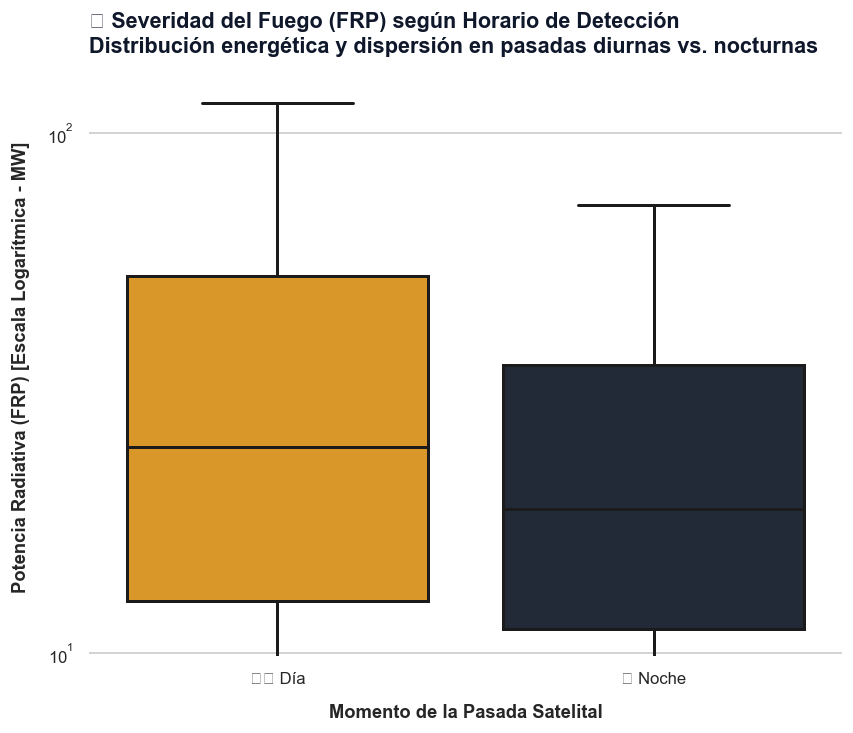

In [17]:
# 1. Configurar estética de alta definición
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 120  # Nitidez óptima

def plot_fire_severity_day_night(dataframe):
    # Crear copia interna para evitar SettingWithCopyWarning
    df_temp = dataframe.copy()
    
    # Comprobación de seguridad para la columna daynight
    if 'daynight' not in df_temp.columns:
        raise ValueError("El DataFrame no contiene la columna 'daynight'")

    # SOLUCON ANTI-CHOF: Definimos una proporción vertical/cuadrada saludable
    # Un boxplot de pocas categorías (Día vs Noche) se ve mejor en formato 7x6 o similar
    fig, ax = plt.subplots(figsize=(7, 6), layout="constrained")

    # Mapeo estético para que el eje X sea totalmente explícito y elegante
    df_temp['daynight_label'] = df_temp['daynight'].map({'D': '☀️ Día', 'N': '🌙 Noche'})
    
    # 2. Gráfico de caja (Boxplot) de Alta Fidelidad
    sns.boxplot(
        ax=ax, 
        data=df_temp, 
        x='daynight_label', 
        y='frp', 
        hue='daynight_label',
        showfliers=False,       # Oculta outliers extremos para que la caja "respire" bien
        palette=['#f59e0b', '#1e293b'], # Ámbar para el día, Pizarra oscuro para la noche
        linewidth=1.8,
        legend=False
    )
    
    # 3. Escala adaptativa inteligente (Logarítmica si los datos están muy dispersos)
    if df_temp['frp'].max() / df_temp['frp'].median() > 15:
        ax.set_yscale('log')
        ax.set_ylabel('Potencia Radiativa (FRP) [Escala Logarítmica - MW]', fontsize=11, fontweight='semibold', labelpad=10)
    else:
        ax.set_ylabel('Potencia Radiativa del Fuego (FRP - MW)', fontsize=11, fontweight='semibold', labelpad=10)

    # 4. Refinamiento de etiquetas y títulos estilo Dashboard Senior
    ax.set_xlabel('Momento de la Pasada Satelital', fontsize=11, fontweight='semibold', labelpad=10)
    ax.tick_params(labelsize=10)
    
    plt.title('🔥 Severidad del Fuego (FRP) según Horario de Detección\n'
              'Distribución energética y dispersión en pasadas diurnas vs. nocturnas', 
              fontsize=13, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.3)
    
    # Limpieza de bordes innecesarios
    sns.despine(left=True, bottom=True)
    
    return fig

# Lanzamiento directo sobre tu df_clean
fig_severity = plot_fire_severity_day_night(df_clean)
plt.show()

#### **Análisis de Intensidad (Distribución de FRP y Brillo)**

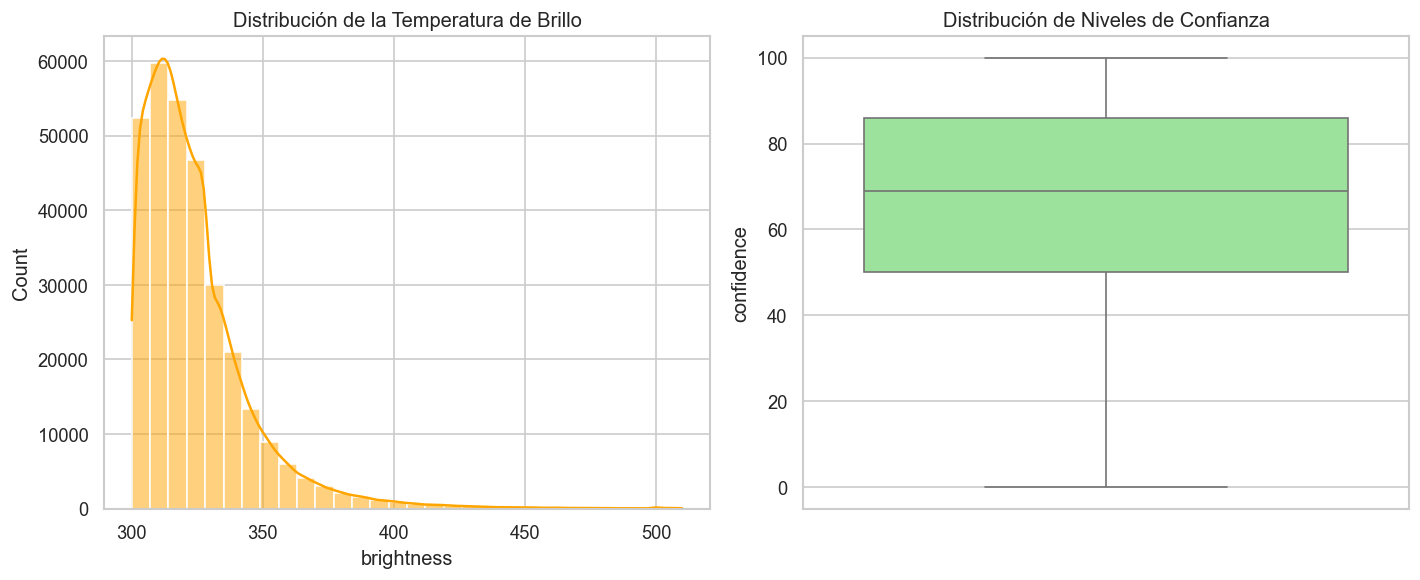

In [18]:
# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Histograma de la potencia radiativa del fuego (FRP) o brillo
plt.subplot(1, 2, 1)
sns.histplot(df['brightness'], bins=30, kde=True, color='orange')
plt.title('Distribución de la Temperatura de Brillo')

# Boxplot de Confianza para ver si hay anomalías o ruido
plt.subplot(1, 2, 2)
sns.boxplot(y=df['confidence'], color='lightgreen')
plt.title('Distribución de Niveles de Confianza')

plt.tight_layout()
plt.show()

#### **Distribución Geoespacial Rápida (Scatter Plot)**

C:\Users\Usuario\AppData\Local\Temp\ipykernel_21436\458028765.py:54: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


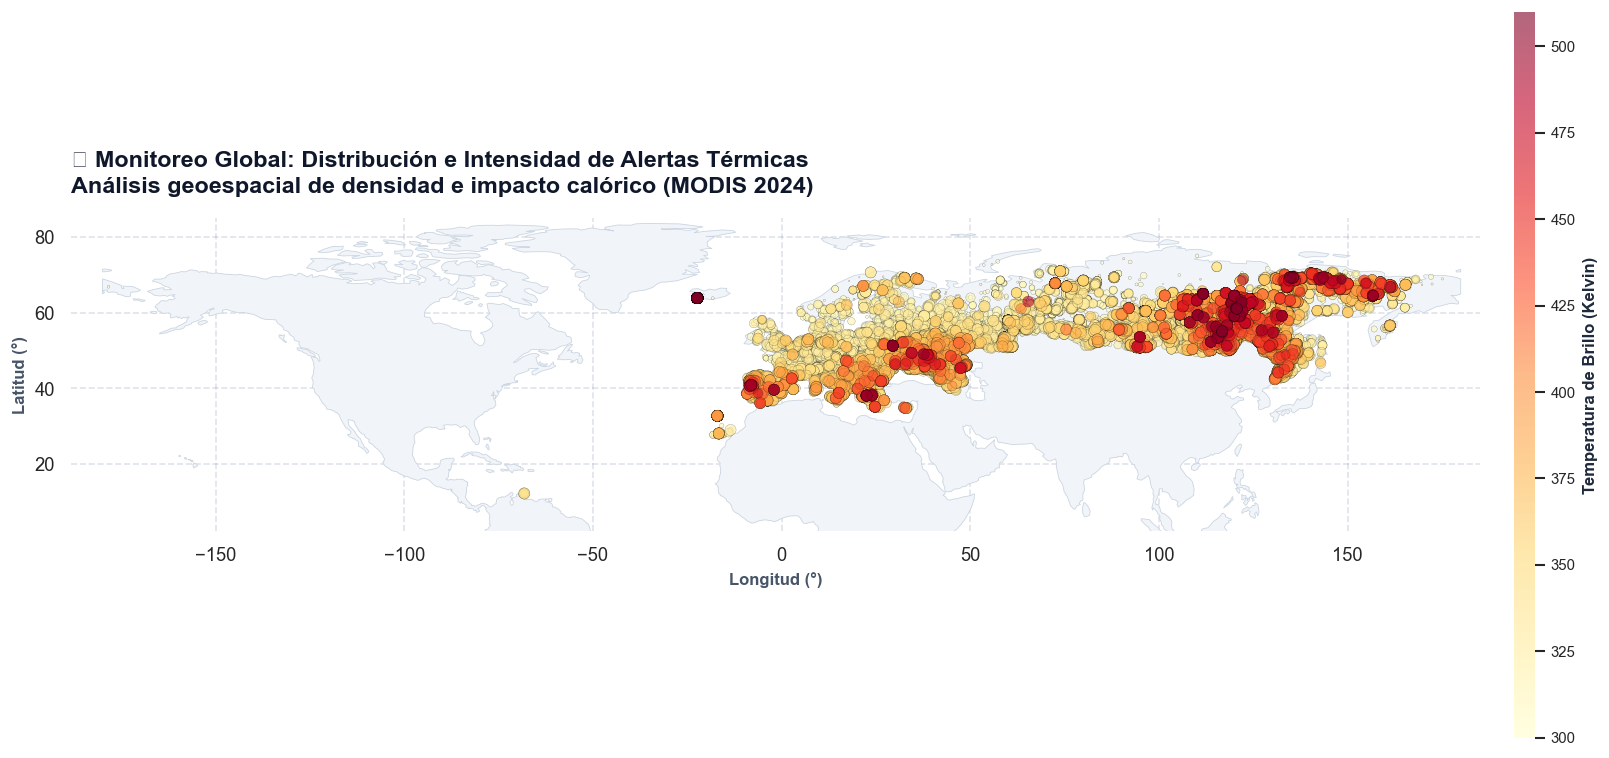

In [19]:
# 1. Configurar entorno estético nativo de Jupyter
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 120  

def render_pro_map_with_background(dataframe):
    fig, ax = plt.subplots(figsize=(15, 9))
    
    # === SOLUCIÓN: Cargar el mapa desde el nuevo paquete oficial ===
    url_world = geodatasets.get_path("naturalearth.land")
    world = gpd.read_file(url_world)
    world.plot(ax=ax, color='#f1f5f9', edgecolor='#cbd5e1', linewidth=0.5)
    
    # 2. Pipeline de datos: Evitar Overplotting (Fuegos intensos al frente)
    df_sorted = dataframe.sort_values(by='brightness', ascending=True)
    
    # Escalado semántico para el tamaño basado en confianza
    sizes = (df_sorted['confidence'] / 100) ** 2 * 45

    # 3. Renderizado de las Alertas Térmicas sobre el mapa
    scatter = ax.scatter(
        x=df_sorted['longitude'],
        y=df_sorted['latitude'],
        c=df_sorted['brightness'],
        s=sizes,
        cmap='YlOrRd',       
        alpha=0.6,           
        edgecolors='black',  
        linewidths=0.15,
        zorder=3             # Garantiza que los puntos queden por encima del mapa
    )

    # 4. Estilizado de la barra de color
    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, aspect=35, shrink=0.7)
    cbar.set_label('Temperatura de Brillo (Kelvin)', fontsize=10, fontweight='semibold', color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False) 

    # 5. Límites geográficos adaptados a tus datos
    ax.set_xlim(dataframe['longitude'].min() - 10, dataframe['longitude'].max() + 10)
    ax.set_ylim(dataframe['latitude'].min() - 10, dataframe['latitude'].max() + 10)

    # 6. Arquitectura de Diseño
    ax.set_title('🔥 Monitoreo Global: Distribución e Intensidad de Alertas Térmicas\n'
                 'Análisis geoespacial de densidad e impacto calórico (MODIS 2024)', 
                 fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a',
                 linespacing=1.4)
    
    ax.set_xlabel('Longitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    ax.set_ylabel('Latitud (°)', fontsize=10, fontweight='semibold', color='#475569')
    
    sns.despine(left=True, bottom=True)
    ax.grid(True, linestyle='--', alpha=0.3, color='#94a3b8')
    
    plt.tight_layout()
    return fig

# Lanzar el gráfico definitivo
fig = render_pro_map_with_background(df)
plt.show()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


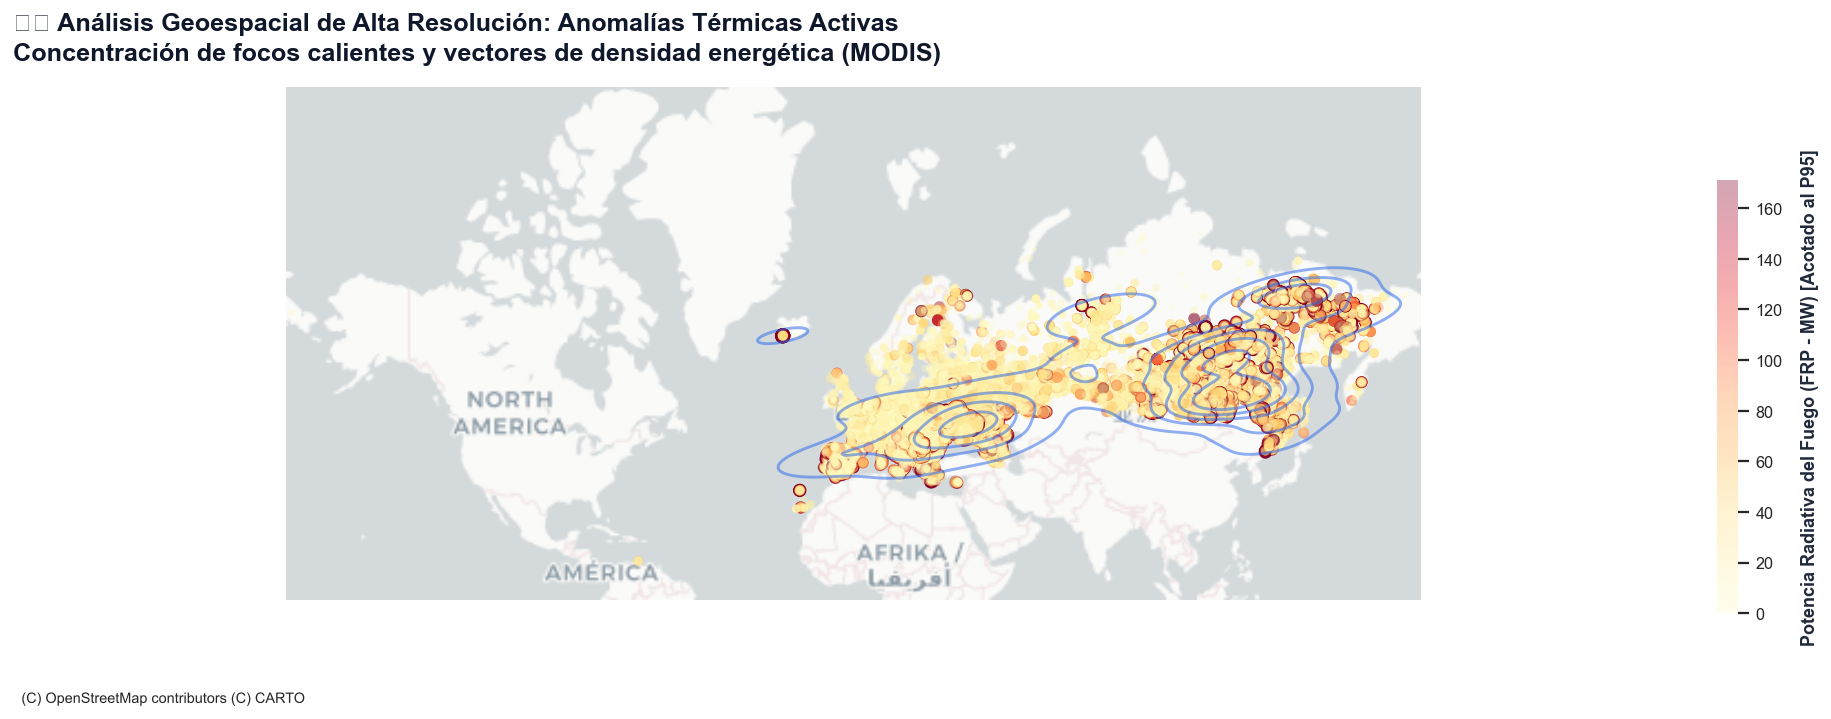

In [20]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx

# Configurar entorno estético
sns.set_theme(style="white", context="notebook")
plt.rcParams['figure.dpi'] = 130

def render_mapa_perfecto(dataframe):
    # 1. Convertir el DataFrame a un GeoDataFrame (fijando WGS84 - EPSG:4326)
    gdf = gpd.GeoDataFrame(
        dataframe, 
        geometry=gpd.points_from_xy(dataframe['longitude'], dataframe['latitude']),
        crs="EPSG:4326"
    )
    
    # 2. Transformar automáticamente a Web Mercator (EPSG:3857), que es el que usa CartoDB
    gdf = gdf.to_crs(epsg=3857)
    
    # Extraer las coordenadas ya proyectadas de forma segura
    x = gdf.geometry.x
    y = gdf.geometry.y

    # Calcular dimensiones para el aspecto automático
    ancho_datos = x.max() - x.min() if len(x) > 1 else 150000
    alto_datos = y.max() - y.min() if len(y) > 1 else 150000
    aspect_ratio_datos = alto_datos / ancho_datos

    ancho_fig = 14
    alto_fig = max(6, min(ancho_fig * aspect_ratio_datos, 11))

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig), layout="constrained")
    ax.set_aspect('equal', adjustable='datalim')

    v_max = gdf['frp'].quantile(0.95)

    # 3. Graficar focos de calor
    scatter = ax.scatter(
        x=x, y=y,
        c=gdf['frp'], cmap='YlOrRd',
        s=np.log1p(gdf['frp']) * 8, 
        alpha=0.35, 
        edgecolors='none', 
        norm=plt.Normalize(vmin=0, vmax=v_max),
        zorder=2
    )

    # 4. Curvas KDE con muestreo dinámico
    if len(gdf) > 5000:
        gdf_kde = gdf.sample(5000, random_state=42)
    else:
        gdf_kde = gdf

    sns.kdeplot(
        x=gdf_kde.geometry.x, y=gdf_kde.geometry.y, ax=ax,
        levels=6, color='#2563eb', linewidths=1.6, alpha=0.5,
        zorder=3
    )

    # 5. Mapa base elegante (Ahora sí encajará al 100%)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zorder=1)

    # 6. Padding adaptativo
    pad_x = ancho_datos * 0.08
    pad_y = alto_datos * 0.08
    ax.set_xlim(x.min() - pad_x, x.max() + pad_x)
    ax.set_ylim(y.min() - pad_y, y.max() + pad_y)

    # 7. Limpieza y Barra de color
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.7)
    cbar.set_label('Potencia Radiativa del Fuego (FRP - MW) [Acotado al P95]', 
                   fontsize=10, fontweight='semibold', labelpad=10, color='#1e293b')
    cbar.ax.tick_params(labelsize=9)
    cbar.outline.set_visible(False)

    plt.title('🗺️ Análisis Geoespacial de Alta Resolución: Anomalías Térmicas Activas\n'
              'Concentración de focos calientes y vectores de densidad energética (MODIS)', 
              fontsize=14, fontweight='bold', pad=15, loc='left', color='#0f172a', linespacing=1.4)
    
    sns.despine(left=True, bottom=True)
    return fig

# Ejecutar
fig_mapa_premium = render_mapa_perfecto(df_clean)
plt.show()



### **Mapa Folium**

In [22]:
import io
import folium
from folium.plugins import HeatMap

# 2. Calcular el centro del mapa basado en los datos
centro_lat = df_clean["latitude"].mean()
centro_lon = df_clean["longitude"].mean()

# 3. Inicializar el mapa base de Folium
# Usamos un zoom inicial de 8 para centrarlo bien en la zona (Albania en este caso)
mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=8, tiles="OpenStreetMap")

# 4. Preparar los datos para el HeatMap
# Pasamos latitud, longitud y usamos 'brightness' como peso/intensidad del foco
datos_focos = df_clean[["latitude", "longitude", "brightness"]].values.tolist()

# 5. Crear y añadir la capa de calor al mapa
HeatMap(
    data=datos_focos,
    radius=15,  # Radio de influencia de cada foco en píxeles
    blur=10,  # Grado de desenfoque para suavizar el mapa de calor
    max_zoom=13,  # Zoom a partir del cual el punto tiene la máxima intensidad
).add_to(mapa)

# 6. Guardar o mostrar el mapa
# Si estás en un Jupyter Notebook / Streamlit basta con llamar a 'mapa'
# Para guardarlo en HTML:
mapa.save("mapa_de_focos.html")

# **Reporte de Análisis Exploratorio de Datos (EDA)**

### **Dataset:** Alertas de Anomalías Térmicas (MODIS 2024)



---

## 1. Resumen Ejecutivo

El conjunto de datos analizado corresponde a las detecciones de anomalías térmicas (focos de calor e incendios) capturadas por el instrumento **MODIS** a bordo de los satélites **Terra** y **Aqua** durante el año **2024**. El conjunto de datos original consolida información de múltiples países con un total de **308,402 registros** y 16 variables iniciales. Tras un proceso riguroso de limpieza, normalización y filtrado de ruido, el dataset quedó optimizado para el análisis.

---

## 2. Calidad de los Datos y Proceso de Limpieza

### **Diagnóstico Inicial**

* **Volumen:** 308,402 filas y 16 columnas.


* **Integridad:** El dataset inicial presentó una **calidad excepcional en términos de completitud, registrando un 0% de valores nulos** en todas sus variables.



### **Transformaciones y Optimizaciones Aplicadas**

1. **Formateo de Tiempo:** Se convirtieron las variables de adquisición (`acq_date` y `acq_time`) y se consolidaron en una única variable de tipo fecha-hora (`acq_datetime`) para permitir análisis de series temporales precisos.


2. **Validación Geográfica:** Se validó que el 100% de las coordenadas estuvieran en los rangos lógicos (Latitud: $-90$ a $90$; Longitud: $-180$ a $180$).


3. **Optimización de Memoria:** Variables con alta repetitividad (`satellite`, `instrument`, `daynight`, `pais`, `type`) fueron transformadas al tipo de dato `category`. Las variables numéricas de temperatura y potencia (`brightness`, `bright_t31`, `frp`) se redondearon a dos decimales, reduciendo el uso de memoria a **49.1 MB**.


4. **Mapeo de Negocio:** La columna categórica `type` fue decodificada desde sus valores numéricos originales a etiquetas legibles:


* **0:** Incendio forestal/vegetación


* **1:** Volcán


* **2:** Industria/Foco estático


* **3:** Otros/Fuera de rango





---

## 3. Análisis Descriptivo e Interpretación de Variables

### **Distribución de Tipos de Focos Térmicos**

Una vez aplicado el mapeo, se observa la siguiente distribución en el dataset:

| Tipo de Foco Térmico | Cantidad de Alertas | Porcentaje |
| --- | --- | --- |
| **Incendio forestal/vegetación** | 279,748 | 90.71% |
| **Industria/Foco estático** | 26,770 | 8.68% |
| **Volcán** | 1,760 | 0.57% |
| **Otros/Fuera de rango** | 124 | 0.04% |

> 📌 **Interpretación:** Más del **90% de las alertas** corresponden a incendios forestales o de vegetación. Esto demuestra que el dataset está masivamente orientado al monitoreo ambiental y de emergencias por fuego, dejando las actividades industriales y volcánicas como eventos secundarios o ruido de fondo controlado.
> 
> 

### **Análisis de la Confianza (Filtro de Ruido)**

La variable `confidence` (0-100%) mide la certidumbre del algoritmo de MODIS sobre si el píxel detectado representa un fuego real.

* **Media original:** 66.09%.


* **Mediana (Percentil 50):** 69.00%.



El EDA propone una estrategia de **limpieza de ruido** eliminando las alertas con confianza baja ($< 50\%$).

* **Registros útiles (Confianza $\ge 50\%$):** 231,964 alertas.


* **Ruido/Falsos positivos eliminados:** 76,438 alertas (24.78% del total).



> 📌 **Interpretación:** Uno de cada cuatro registros originales de MODIS es potencialmente un falso positivo o una medición de baja fiabilidad. Para el entrenamiento de modelos predictivos o análisis de riesgo sectorial, **es mandatorio trabajar con el subset filtrado de 231,964 alertas** para asegurar la precisión de las conclusiones.
> 
> 

---

## 5. Próximos Pasos Sugeridos para el Análisis (Next Steps)

Dado que el archivo ya fue exportado de manera limpia (`modis_2024_unificado_limpio.csv`), se recomienda proceder con:

1. **Análisis Temporal:** Evaluar la estacionalidad de las alertas por mes y las diferencias entre detecciones diurnas y nocturnas (`daynight`).


2. **Análisis Geográfico:** Utilizar las variables `latitude`, `longitude` y `pais` para mapear los clústeres o "hotspots" de mayor afectación por incendios forestales.


3. **Análisis de Intensidad:** Cruzar la Potencia Radiactiva del Fuego (`frp`) con la temperatura de brillo (`brightness`) para categorizar la gravedad y magnitud de los incendios detectados.